# Quality Control Example

This notebook demonstrates the `dynamic_foraging_processing.qc` module: the
**metrics** that can be gathered and the **plots** that can be produced from the
per-trial `animal_response` (`0` left, `1` right, `2` ignore).

It uses **synthetic data** (no dataset loading) so it runs anywhere, mirroring
the arrays used in the unit tests. Swap in a real session's `animal_response`
(e.g. the `animal_response` column from `TrialTableBuilder.build()`) to use it
for real.

## Create synthetic data

A random per-trial choice sequence, plus the optional per-trial context the
side-bias figure can display (reward history, reward probabilities, autowater,
go-cue times). None of this needs a dataset.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(0)
n_trials = 200

# Choice per trial: 0 left, 1 right, 2 ignore (slightly right-biased here).
animal_response = rng.choice([0, 1, 2], size=n_trials, p=[0.4, 0.5, 0.1])

# Optional per-trial context (synthetic), one array per column.
rewarded_left = (animal_response == 0) & (rng.random(n_trials) < 0.5)
rewarded_right = (animal_response == 1) & (rng.random(n_trials) < 0.5)
autowater_left = np.zeros(n_trials, int)
autowater_right = np.zeros(n_trials, int)
reward_probability_left = np.full(n_trials, 0.4)
reward_probability_right = np.full(n_trials, 0.6)
go_cue_times = np.arange(n_trials, dtype=float)

print("n trials:", n_trials)
print("left  (0):", int(np.sum(animal_response == 0)))
print("right (1):", int(np.sum(animal_response == 1)))
print("ignore(2):", int(np.sum(animal_response == 2)))

n trials: 200
left  (0): 70
right (1): 100
ignore(2): 30


## Metrics from `animal_response`

### Average side bias
`compute_side_bias` returns `mean(is_right) - mean(is_left)` over responded
trials, in `[-1, +1]` (positive = rightward bias).

In [2]:
from dynamic_foraging_processing.qc import compute_side_bias

mean_bias = compute_side_bias(animal_response)
print(f"average side bias: {mean_bias:.3f}")

average side bias: 0.176


### Rolling side bias (with confidence band)
`compute_rolling_bias` returns a trailing-window bias trace and a 95% normal-
approximation confidence interval, one row per trial.

In [3]:
from dynamic_foraging_processing.qc import compute_rolling_bias

bias, ci = compute_rolling_bias(animal_response, window=20)
print("bias shape:", bias.shape, "| ci shape:", ci.shape)
pd.DataFrame({"bias": bias, "ci_low": ci[:, 0], "ci_high": ci[:, 1]}).head()

bias shape: (200,) | ci shape: (200, 2)


,bias,ci_low,ci_high
0,1.000000,1.000000,1.000000
1,0.000000,-1.385929,1.385929
2,-0.333333,-1.400222,0.733556
3,-0.500000,-1.348705,0.348705
4,-0.200000,-1.058829,0.658829


### As a QC result / metric
`side_bias_result` wraps the scalar into a `QCResult` (pass when
`abs(bias) < 0.5`), which converts to an `aind_data_schema` `QCMetric`.

In [4]:
from dynamic_foraging_processing.qc import side_bias_result

result = side_bias_result(animal_response)
print("name:   ", result.name)
print("value:  ", result.value)
print("passed: ", result.passed)
print("tags:   ", result.tags)

metric = result.to_metric()
metric

name:    average side bias
value:   0.17647058823529416
passed:  True
tags:    {'behavior': 'average side bias'}


QCMetric(object_type='QC metric', name='average side bias', modality=_Behavior(name='Behavior', abbreviation='behavior'), stage='Raw data', value=0.17647058823529416, status_history=[QCStatus(object_type='QC status', evaluator='Automated', status='Pass', timestamp=datetime.datetime(2026, 6, 17, 16, 17, 0, 236255, tzinfo=zoneinfo.ZoneInfo(key='America/Los_Angeles')))], description='Average side bias over responded trials (right minus left).', reference='side_bias.png', tags={'behavior': 'average side bias'}, evaluated_assets=None)

## Plot: side-bias figure

`plot_side_bias` writes a four-panel `side_bias.png` into a results folder:
rolling side bias, lickspout position, per-trial behavior raster, and reward
probabilities. It is driven by `animal_response`; the remaining panels are
populated from the optional per-trial context created above.

In [5]:
from pathlib import Path

from dynamic_foraging_processing.qc import plot_side_bias

results_folder = Path("qc_results")
results_folder.mkdir(exist_ok=True)

plot_side_bias(
    animal_response,
    str(results_folder),
    rewarded_left=rewarded_left,
    rewarded_right=rewarded_right,
    reward_probability_left=reward_probability_left,
    reward_probability_right=reward_probability_right,
    go_cue_times=go_cue_times,
    autowater_left=autowater_left,
    autowater_right=autowater_right,
    bias_window=20,
)

'side_bias.png'

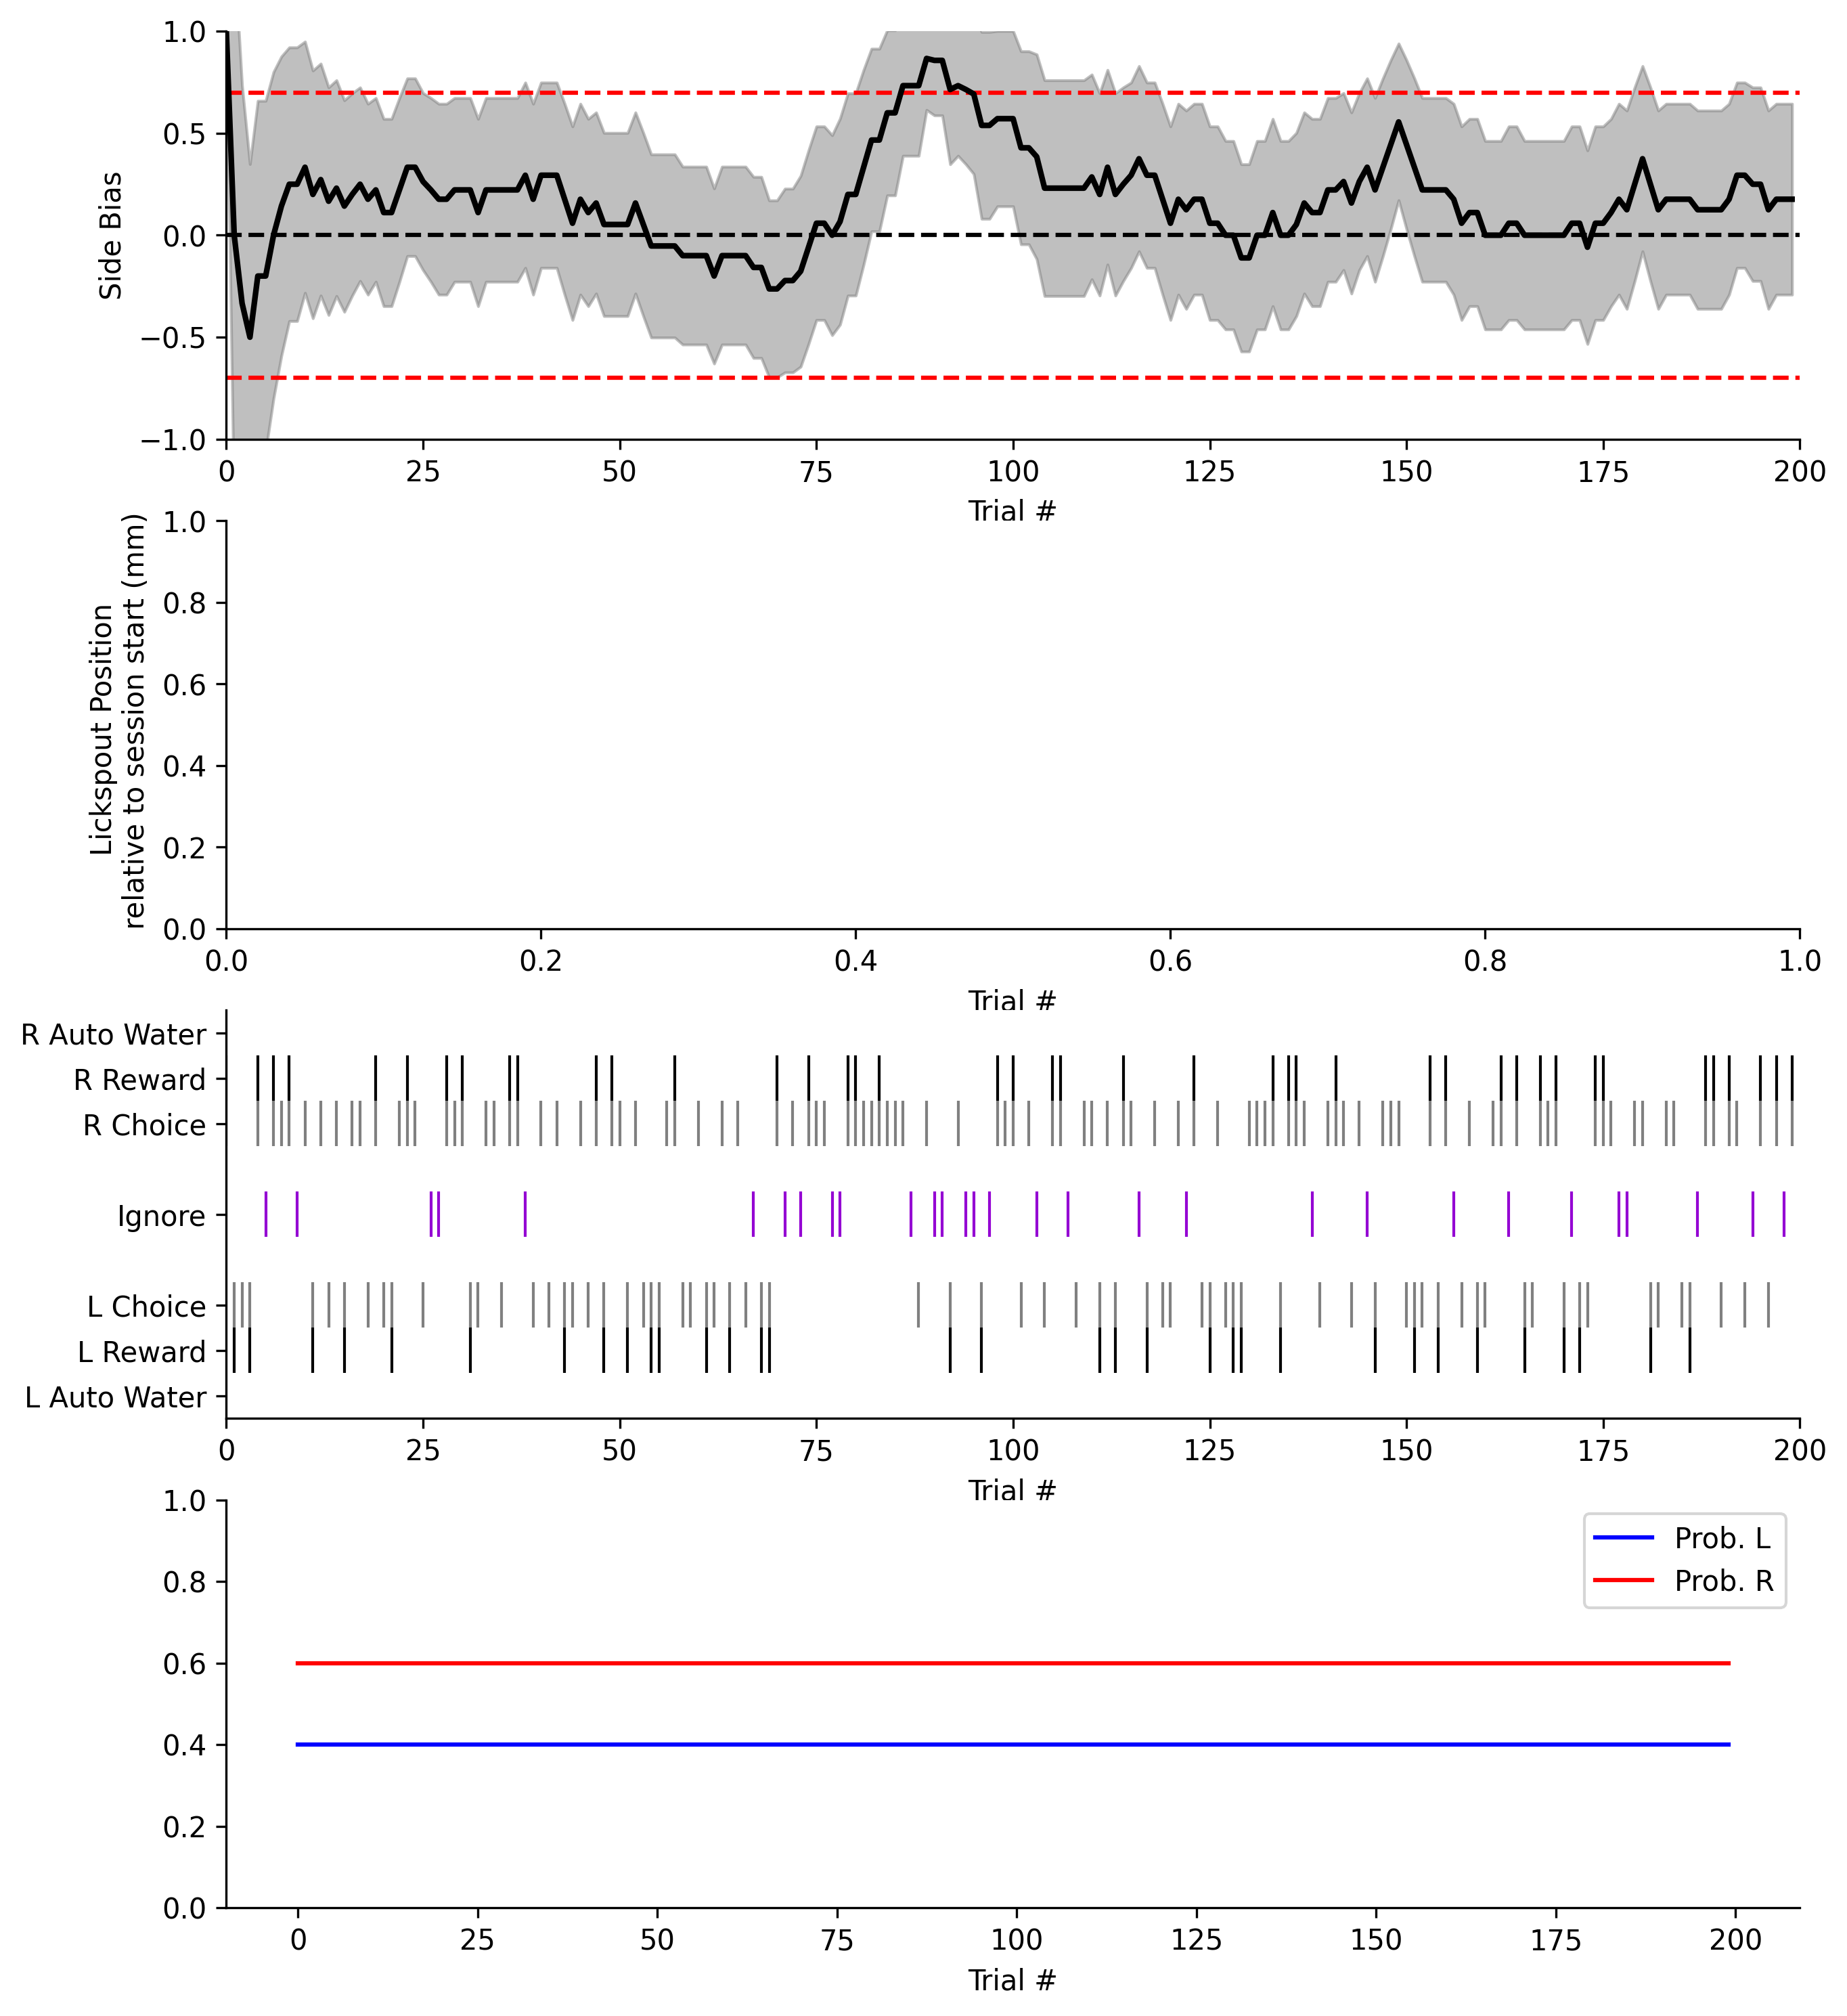

In [6]:
from IPython.display import Image

Image(filename=str(results_folder / "side_bias.png"))

## Assemble a `QualityControl` object

Collect the behavior metric(s) into a single `QualityControl`. In a real
pipeline you would also append the automated contract-QA metrics
(`contract_qc_metrics(dataset, ...)`), which require a loaded dataset.

In [7]:
from dynamic_foraging_processing.qc import build_quality_control

quality_control = build_quality_control([metric])
print("total metrics:", len(quality_control.metrics))
print("default grouping:", quality_control.default_grouping)
quality_control

total metrics: 1
default grouping: ['behavior', 'test_suite']


QualityControl(object_type='Quality control', describedBy='https://raw.githubusercontent.com/AllenNeuralDynamics/aind-data-schema/main/src/aind_data_schema/core/quality_control.py', schema_version='2.4.2', metrics=[QCMetric(object_type='QC metric', name='average side bias', modality=_Behavior(name='Behavior', abbreviation='behavior'), stage='Raw data', value=0.17647058823529416, status_history=[QCStatus(object_type='QC status', evaluator='Automated', status='Pass', timestamp=datetime.datetime(2026, 6, 17, 16, 17, 0, 236255, tzinfo=zoneinfo.ZoneInfo(key='America/Los_Angeles')))], description='Average side bias over responded trials (right minus left).', reference='side_bias.png', tags={'behavior': 'average side bias'}, evaluated_assets=None)], key_experimenters=None, notes=None, default_grouping=['behavior', 'test_suite'], allow_tag_failures=[], status={'behavior:average side bias': <Status.PASS: 'Pass'>, 'behavior': <Status.PASS: 'Pass'>, 'Raw data': <Status.PASS: 'Pass'>})